# Training CNN from Scratch with MNIST - PyTorch Version

In [1]:
# IMPORTS
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

***1.*** ***Load and preprocess MNIST dataset***

In [2]:
transforms = transforms.Compose([
    transforms.ToTensor(),# Converts to [0,1]
    transforms.Normalize((0.1307,),(0.3081,)) # Normalizes with MNIST mean & std
])

train_dataset = datasets.MNIST(root='./data',train=True,download=True,transform=transforms)
test_dataset = datasets.MNIST(root='./data',train=False,download=True,transform=transforms)

train_loader = DataLoader(train_dataset,batch_size=64,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=1000,shuffle=False)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.02MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.08MB/s]


***2. Visualize some images***

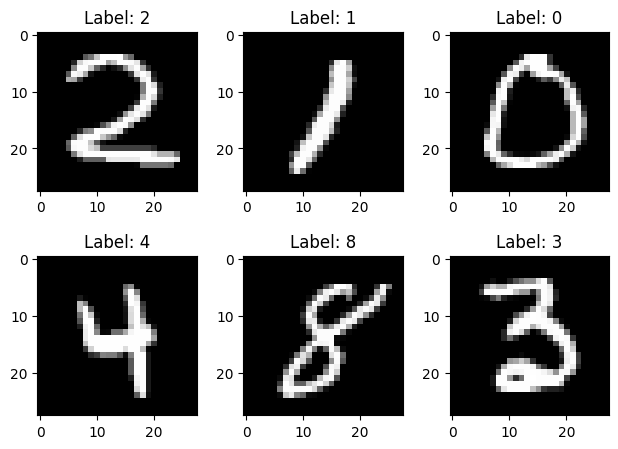

In [3]:
ex = enumerate(train_loader)
batch_idx, (ex_data,ex_target) = next(ex)

fig = plt.figure()
for i in range(6):
  plt.subplot(2,3,i+1)
  plt.tight_layout()
  plt.imshow(ex_data[i][0],cmap='gray',interpolation='none')
  plt.title("Label: {}".format(ex_target[i]))
  plt.xticks()
  plt.yticks()
plt.show()

***3. Define CNN architecture***

In [4]:
class CNN(nn.Module):
  def __init__(self):
    super(CNN,self).__init__()
    self.conv1 = nn.Conv2d(1,32,kernel_size=3)
    self.conv2 = nn.Conv2d(32,64,kernel_size=3)
    self.dropout1 = nn.Dropout2d(0.25)
    self.dropout2 = nn.Dropout2d(0.5)
    self.fc1 = nn.Linear(9216,128)
    self.fc2 = nn.Linear(128,10)


  def forward(self,x):
    x = F.relu(self.conv1(x)) # batch [32,26,26]
    x = F.relu(self.conv2(x)) # batch [64,24,24]
    x = F.max_pool2d(x,2)     # batch [64,12,12]
    x = self.dropout1(x)
    x = torch.flatten(x,1)    # Flatten all but batch
    x = F.relu(self.fc1(x))
    x = self.dropout2(x)
    x = self.fc2(x)
    return F.log_softmax(x,dim=1)

***4. Instantiate model, define optimizer and loss***

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else 'cpu')
print(device)
model=CNN().to(device)
optimizer = optim.Adam(model.parameters(),lr=0.001)

cuda


***5. Training loop***

In [7]:
def train_model(model,device,train_loader,optimizer,epoch):
  model.train()
  for batch_idx,(data,target) in enumerate(train_loader):
    data,target = data.to(device),target.to(device)

    optimizer.zero_grad()
    output = model(data)
    loss = F.nll_loss(output,target)
    loss.backward()
    optimizer.step()

    if batch_idx % 100 == 0:
      print(f"Train epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)}] Loss: {loss.item():.6f}")

***6. Testing Loop***

In [14]:
from prompt_toolkit import output
def test_model(model,device,test_loader):
  model.eval()
  test_loss = 0
  correct = 0

  with torch.no_grad():
    for data,target in test_loader:
      data,target = data.to(device),target.to(device)
      output = model(data)
      test_loss += F.nll_loss(output,target,reduction='sum').item()
      pred = output.argmax(dim=1)
      correct += pred.eq(target).sum().item()

  test_loss /= len(test_loader.dataset)
  accuracy = 100*correct /len(test_loader.dataset)

  print(f"\nTest set: Average loss: {test_loss:.4f}, Accuracy: {correct}/{len(test_loader.dataset)} ({accuracy:.2f}%)\n")


***7. Run Training and Testing***

In [16]:
for epoch in range(1,6):
  train_model(model,device,train_loader,optimizer,epoch)
  test_model(model,device,test_loader)

Train epoch: 1 [0/60000] Loss: 0.027838
Train epoch: 1 [6400/60000] Loss: 0.023133
Train epoch: 1 [12800/60000] Loss: 0.118283
Train epoch: 1 [19200/60000] Loss: 0.013731
Train epoch: 1 [25600/60000] Loss: 0.015407
Train epoch: 1 [32000/60000] Loss: 0.193374
Train epoch: 1 [38400/60000] Loss: 0.031301
Train epoch: 1 [44800/60000] Loss: 0.134326
Train epoch: 1 [51200/60000] Loss: 0.085094
Train epoch: 1 [57600/60000] Loss: 0.072162

Test set: Average loss: 0.0322, Accuracy: 9889/10000 (98.89%)

Train epoch: 2 [0/60000] Loss: 0.096175
Train epoch: 2 [6400/60000] Loss: 0.006930
Train epoch: 2 [12800/60000] Loss: 0.115944
Train epoch: 2 [19200/60000] Loss: 0.037289
Train epoch: 2 [25600/60000] Loss: 0.157728
Train epoch: 2 [32000/60000] Loss: 0.051630
Train epoch: 2 [38400/60000] Loss: 0.021571
Train epoch: 2 [44800/60000] Loss: 0.017230
Train epoch: 2 [51200/60000] Loss: 0.045286
Train epoch: 2 [57600/60000] Loss: 0.041294

Test set: Average loss: 0.0316, Accuracy: 9893/10000 (98.93%)

Tr

***8. Save the trained model***

In [17]:
model_pth  = "mnist_cnn.pth"
torch.save(model.state_dict(),model_pth)
print(f"Model saved to {model_pth}")

Model saved to mnist_cnn.pth


***9. Load the saved model***

In [18]:
load_model = CNN().to(device)
load_model.load_state_dict(torch.load(model_pth))
load_model.eval()
print("Model loaded succesfully")

Model loaded succesfully


In [19]:
# 10. Make prediction with loaded model
def predict(model,device,data_loader,num_samples):
  model.eval()
  data_iter = iter(data_loader)
  imgs,lbl = next(data_iter)
  imgs,lbl = imgs.to(device),lbl.to(device)
  output = model(imgs)
  pred = output.argmax(1)

  # visualize image
  fig = plt.figure()
  for i in range(num_samples):
    plt.subplot(2,3,i+1)
    plt.tight_layout()
    plt.imshow(imgs[i][0].cpu(),cmap='gray',interpolation='none')
    plt.title(f"Pred: {pred[i].item()},Label: {lbl[i].item()}")
    plt.xticks()
    plt.yticks()
  plt.show()

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/dropout.py:176: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  return F.dropout2d(input, self.p, self.training, self.inplace)


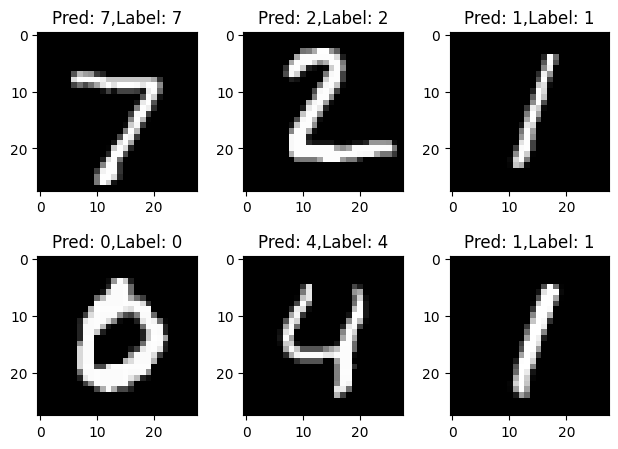

In [20]:
predict(load_model,device,test_loader,6)